In [ ]:
## 모델 불러오기

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import tensorflow as tf

# 시드 고정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 1. Sonar데이터 셋 불러오기
df = pd.read_csv('sonar.csv', header=None)
dataset = df.values

# 2. 입력 X, 정답 y 분리
X = dataset[:, : 60].astype(float)
Y_obj = dataset[:, 60]

# 3. 문자 -> 숫자 : 원-핫 인코딩
e = LabelEncoder()
e.fit(Y_obj)
y = e.transform(Y_obj)

# 4. train x, test y 분리
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

# 5. 저장된 모델 불러오기
model = load_model('my_model.keras')
print('모델이 성공적으로 로드되었습니다')

# 6. 불러온 모델로 테스트 데이터 평가
loss, accuracy = model.evaluate(x_train, y_train)
print("\n Test Accuracy : %.2f" % accuracy)

# 7. 예측 수행
predictions = model.predict(x_train)
print("\n 예측 결과 예시 :", predictions[:5].flatten())
print("실제 정답 :", y_test[:5])

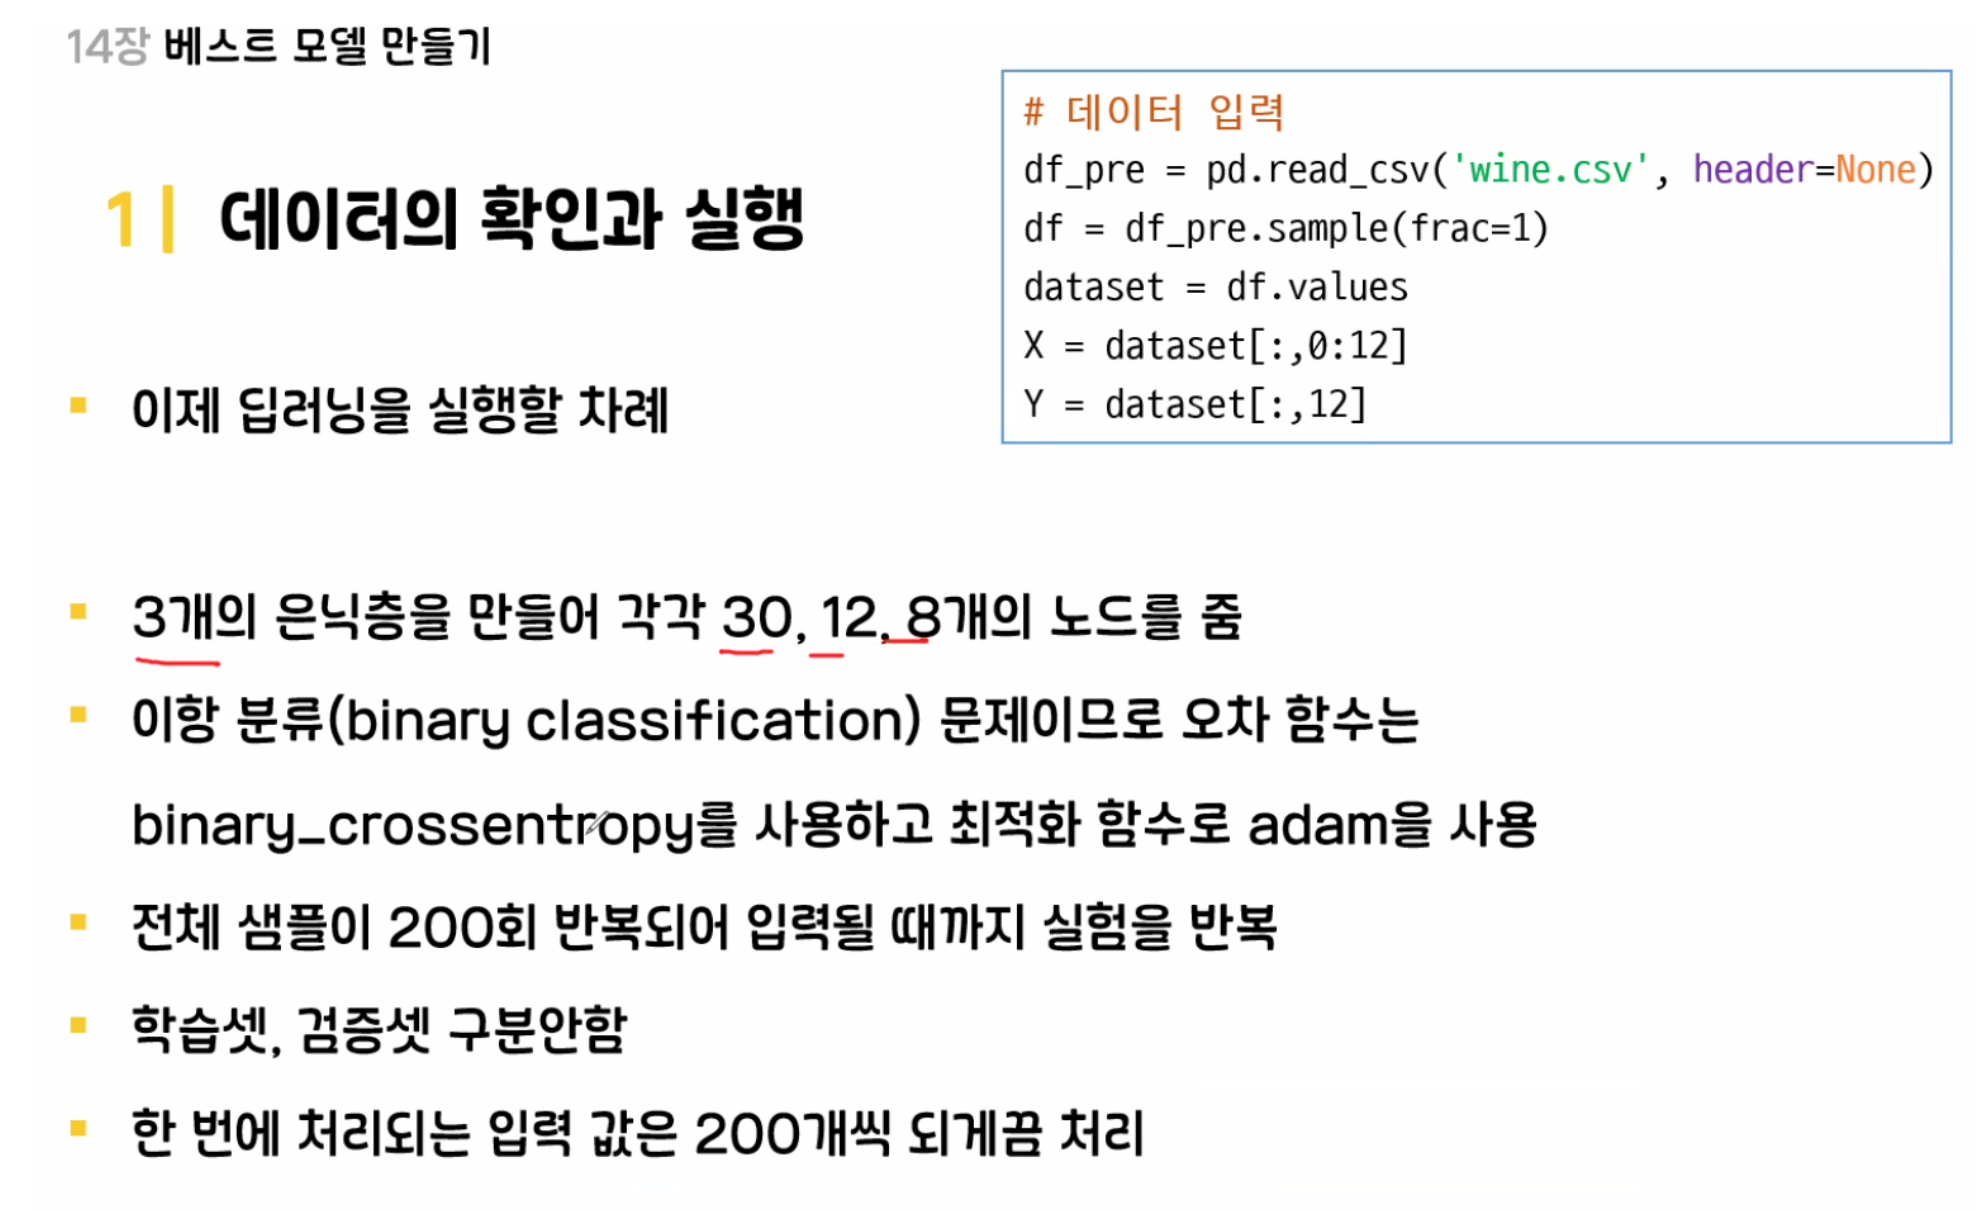

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# seed 값 설정
seed=0
np.random.seed(seed)
tf.random.set_seed(seed)

# 6497개
# 0 ~ 12
# 뭐가 속성이고 클래스인지는 잘...
# 11, 12가 클래스면(int64니까)
# 검색해보니 마지막것만 품질점수, 나머지는 속성 .astype(float64)로 int -> float
df_pre = pd.read_csv('wine.csv', header=None)
df = df_pre.sample(frac=1) # 전체 데이터를 100% 추출하면서 무작위로 가져온다.
# print(df.info())
dataset = df.values
X = dataset[:, 0:12].astype(float)
Y = dataset[:, 12]
# 모델 설정
model = Sequential()
model.add(Input(shape=(12,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 실행
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, Y, epochs=10, batch_size=200) # epochs = 10은 시간 상...

# 모델 평가
scores = model.evaluate(X, Y)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

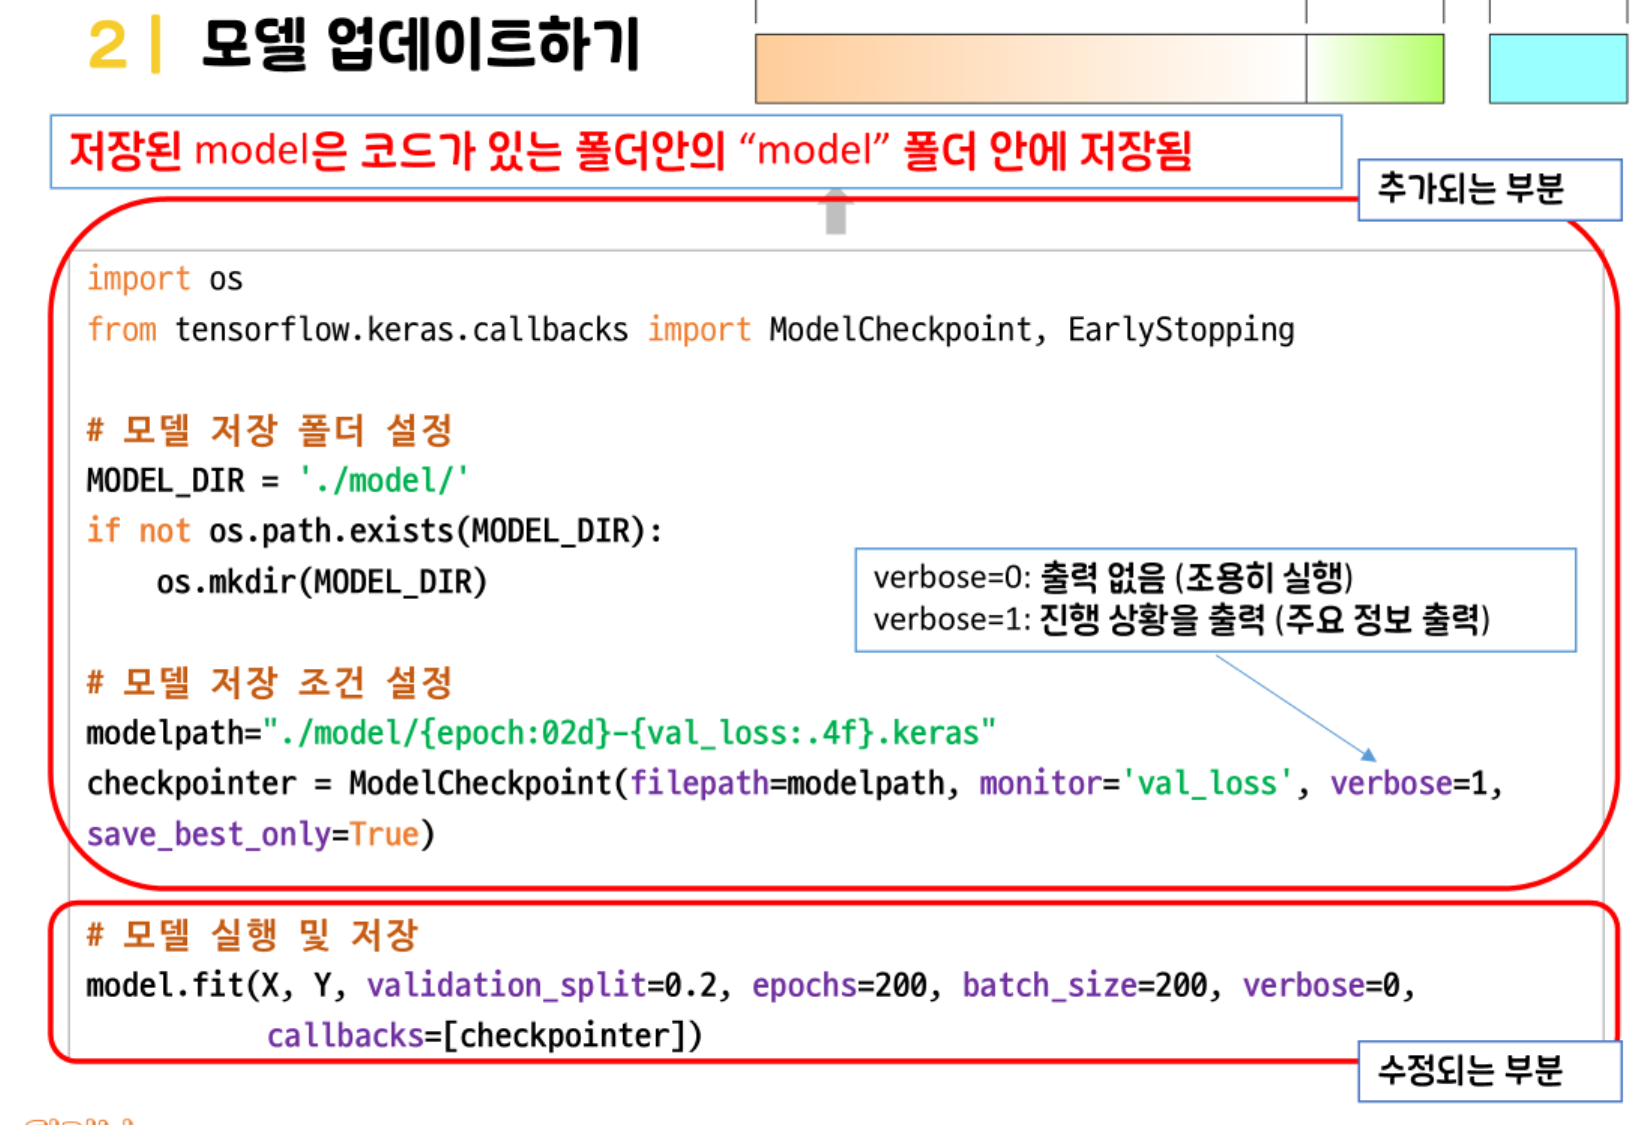

In [ ]:
# 딥러닝 모델 학습 과정 중, 성능이 개선될 때마다 모델 파일을 지정된 폴더에 저장한다.
# modelpath : 저장될 파일명 + 경로
# ModelCheckpoint() : 모델을 저장하는 콜백 함수
# monitor() : 검증 데이터의 '오차'값을 모니터링 기준으로 한다.
# save_best_only = True : 오차 값이 '개선'되었을 때 덮어쓰거나 새로 저장한다.

In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, Earylstopping

# 모델 저장 '폴더' 설정
MODEL_DIR = "./model/"

# 폴더가 없다면 생성
if not os.path.exists(MODEL_DIR):
   os.mkdir(MODEL_DIR)

# 모델 저장 조건 설정
modelpath = MODEL_DIR + "{epoch:02d}-{val_loss:.2f}.keras"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)

# 모델 실행 및 저장
# callbacks : 에포크가 끝날 때마다, checkpointer 호출
model.fit(X, Y, validation_split=0.2, epochs=200, batch_size=200, verbose=0, callbacks=[checkpointer])

In [ ]:
## 위 코드 추가 ##

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# seed 값 설정
seed=0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터 생성
df_pre = pd.read_csv('wine.csv', header=None)
df = df_pre.sample(frac=1) # 전체 데이터를 100% 추출하면서 무작위로 가져온다.
# print(df.info())
dataset = df.values
X = dataset[:, 0:12].astype(float)
Y = dataset[:, 12]

# 모델 설정
model = Sequential()
model.add(Input(shape=(12,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 실행
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# model.fit(X, Y, epochs=10, batch_size=200) # epochs = 10은 시간 상...

MODEL_DIR = "./model/"
if not os.path.exists(MODEL_DIR):
   os.mkdir(MODEL_DIR)

# 모델 저장 조건 설정
model_path = MODEL_DIR + "{epoch:02d}-{val_loss:.2f}.keras"
checkpointer = ModelCheckpoint(filepath=model_path, monitor='val_loss', verbose=0, save_best_only=True)

# 모델 실행 및 저장
model.fit(X, Y, validation_split=0.2, epochs=30, batch_size=200, verbose=0, callbacks=[checkpointer])

# 모델 평가
scores = model.evaluate(X, Y)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

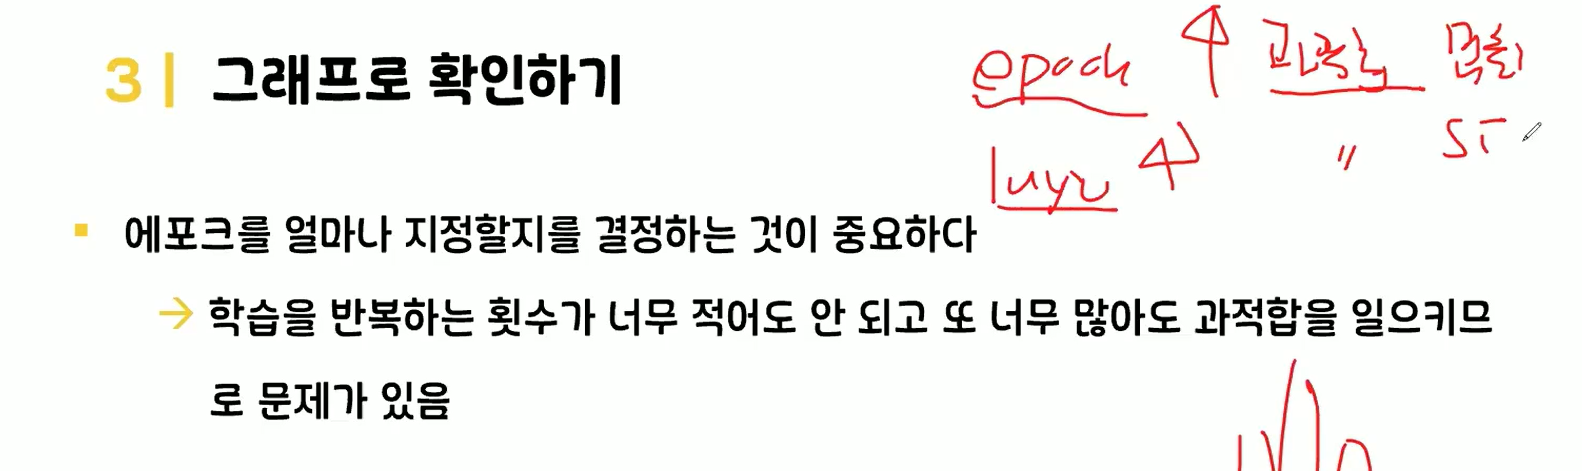

In [ ]:
## 몇번이나 학습을 해야하는지를 해결할 수 있다.
# Wine model save

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import pandas as pd
import numpy as np
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# seed 값 설정
seed=0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
df_pre = pd.read_csv("wine.csv", header=None)
df = df_pre.sample(frac=0.15) # 데이터의 일부분만 가져온다.
# print(df.info)
dataset = df.values
X = dataset[:, :12]
Y = dataset[:, 12]

# 모델 설정
model = Sequential()
model.add(Input(shape=(12,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 컴파일
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 자동 중단 설정
# patience : 모델이 더 좋아지지 않아도 언제까지 에포크를 돌릴지
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=100) 

# 모델 저장 조건 설정
# save_best_only : 향상되면 저장해라
if not os.path.exists('./model'):
    os.mkdir('./model')
modelpath = './model/{epoch:02d}-{val_loss:.4f}.keras'
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)

# 모델 실행
# .history
# loss, accuracy(접두사 X) : 학습셋 결과, val_loss, val_accuracy(접두사 O) : 검증셋 결과
history = model.fit(X, Y, validation_split=0.33, epochs=3500, batch_size=500, callbacks=[early_stopping_callback, checkpointer])


# 결과 출력
print("\n Accuracy: %.4f" % (model.evaluate(X, Y)[1])) # [0]:loss, [1]:accuracy

# y_vloss에 테스트셋으로 실험 결과의 오차 값을 지정
y_vloss = history.history['val_loss']
# y_acc에는 학습셋으로 측정한 정확도의 값을 지정
y_acc = history.history['accuracy']

# x축을 지정하고
# 정확도는 파란색으로, 오차를 빨간색으로 표시
x_len = np.arange(len(y_acc)) # y_acc의 길이만큼, 즉 epoch횟수만큼 -> X축
plt.plot(x_len, y_vloss, "o", c="red", markersize=3)
plt.plot(x_len, y_acc, "o", c="blue", markersize=3)
plt.show()

In [ ]:
# Wine model load

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np

from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split

# 데이터 로드
df = pd.read_csv('wine.csv', header=None)
dataset = df.values

X=dataset[:, :12]
Y=dataset[:, 12]

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

# 모델 로드
model = load_model('./model/305-0.0926.keras') # model폴더 안에서, loss가 가장 작은 keras파일

# 모델 평가
loss, accuracy = model.evaluate(x_test, y_test)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

# 새로운 데이터 예측
new_data = pd.DataFrame({
    'fixed acidity': [7.4, 7.8, 7.8, 11.2, 7.4, 6.2, 6.6, 6.5, 5.5, 6.0],
    'volatile acidity': [0.7, 0.88, 0.76, 0.28, 0.7, 0.21, 0.32, 0.24, 0.29, 0.21],
    'citric acid': [0, 0, 0.04, 0.56, 0, 0.29, 0.36, 0.19, 0.3, 0.38],
    'residual sugar': [1.9, 2.6, 2.3, 1.9, 1.9, 1.6, 8, 1.2, 1.1, 0.8],
    'chlorides': [0.076, 0.098, 0.092, 0.075, 0.076, 0.039, 0.047, 0.041, 0.022, 0.02],
    'free sulfur dioxide': [11, 25, 15, 17, 11, 24, 57, 30, 20, 22],
    'total sulfur dioxide': [34, 67, 54, 60, 34, 92, 168, 111, 110, 98],
    'density': [0.9978, 0.9968, 0.997, 0.998, 0.9978, 0.99114, 0.9949, 0.99254, 0.98869, 0.98941],
    'pH': [3.51, 3.2, 3.26, 3.16, 3.51, 3.27, 3.15, 2.99, 3.34, 3.26],
    'sulphates': [0.56, 0.68, 0.65, 0.58, 0.56, 0.5, 0.46, 0.46, 0.38, 0.32],
    'alcohol': [9.4, 9.8, 9.8, 9.8, 9.4, 11.2, 9.6, 9.4, 12.8, 11.8],
    'taste': [5, 5, 5, 6, 5, 6, 5, 6, 7, 6],
    'quality': [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]  # 실제 구분 등급인 quality 값을 추가(확인용)
})

# 클래스, 속성 분리
actual_quality = new_data['quality'].values
new_data = new_data.drop('quality', axis=1).values

# 예측
predictions = model.predict(new_data)
print('Predictions:', predictions)

predictions = (predictions > 0.5).astype(int).flatten() # 2차원 -> 1차원

# 정확도 계산
accuracy = np.mean(predictions == actual_quality)
print('Predictions:', predictions)
print('Actual:', actual_quality)
print(f'Accuracy: {accuracy * 100:.2f}%')

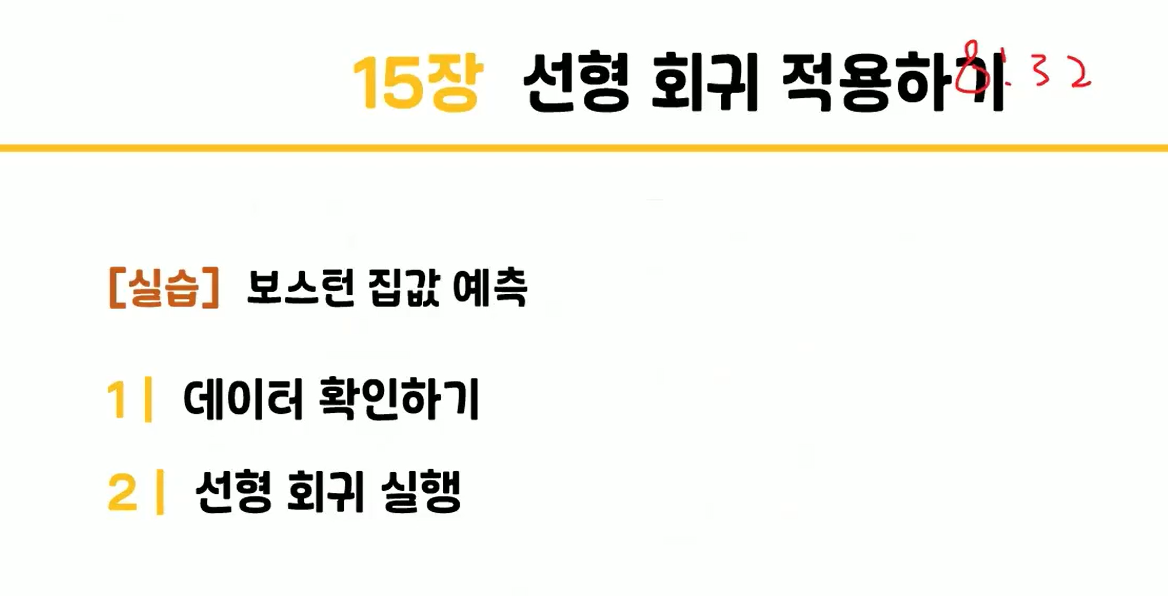

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split

# 시드 고정
seed =0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
df_pre = pd.read_csv('housing.csv', delim_whitespace=True, header=None)
dataset = df_pre.values
# print(df.shape)
X = dataset[:, :13]
Y = dataset[:, 13]
# 분할
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=seed)

# 모델 설정
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(6, activation='relu'))
model.add(Dense(1))

# 모델 컴파일
model.compile(loss='mean_squared_error', optimizer='adam')

# 모델 실행
model.fit(x_train, y_train, epochs=200, batch_size=10)

# 예측 값과 실제 값 비교
y_prediction = model.predict(x_test).flatten()
for i in range(10):
    label = y_test[i]
    prediction = y_prediction[i]
    print("실제가격: {:.3f}, 예상가격: {:.3f}".format(label, prediction))

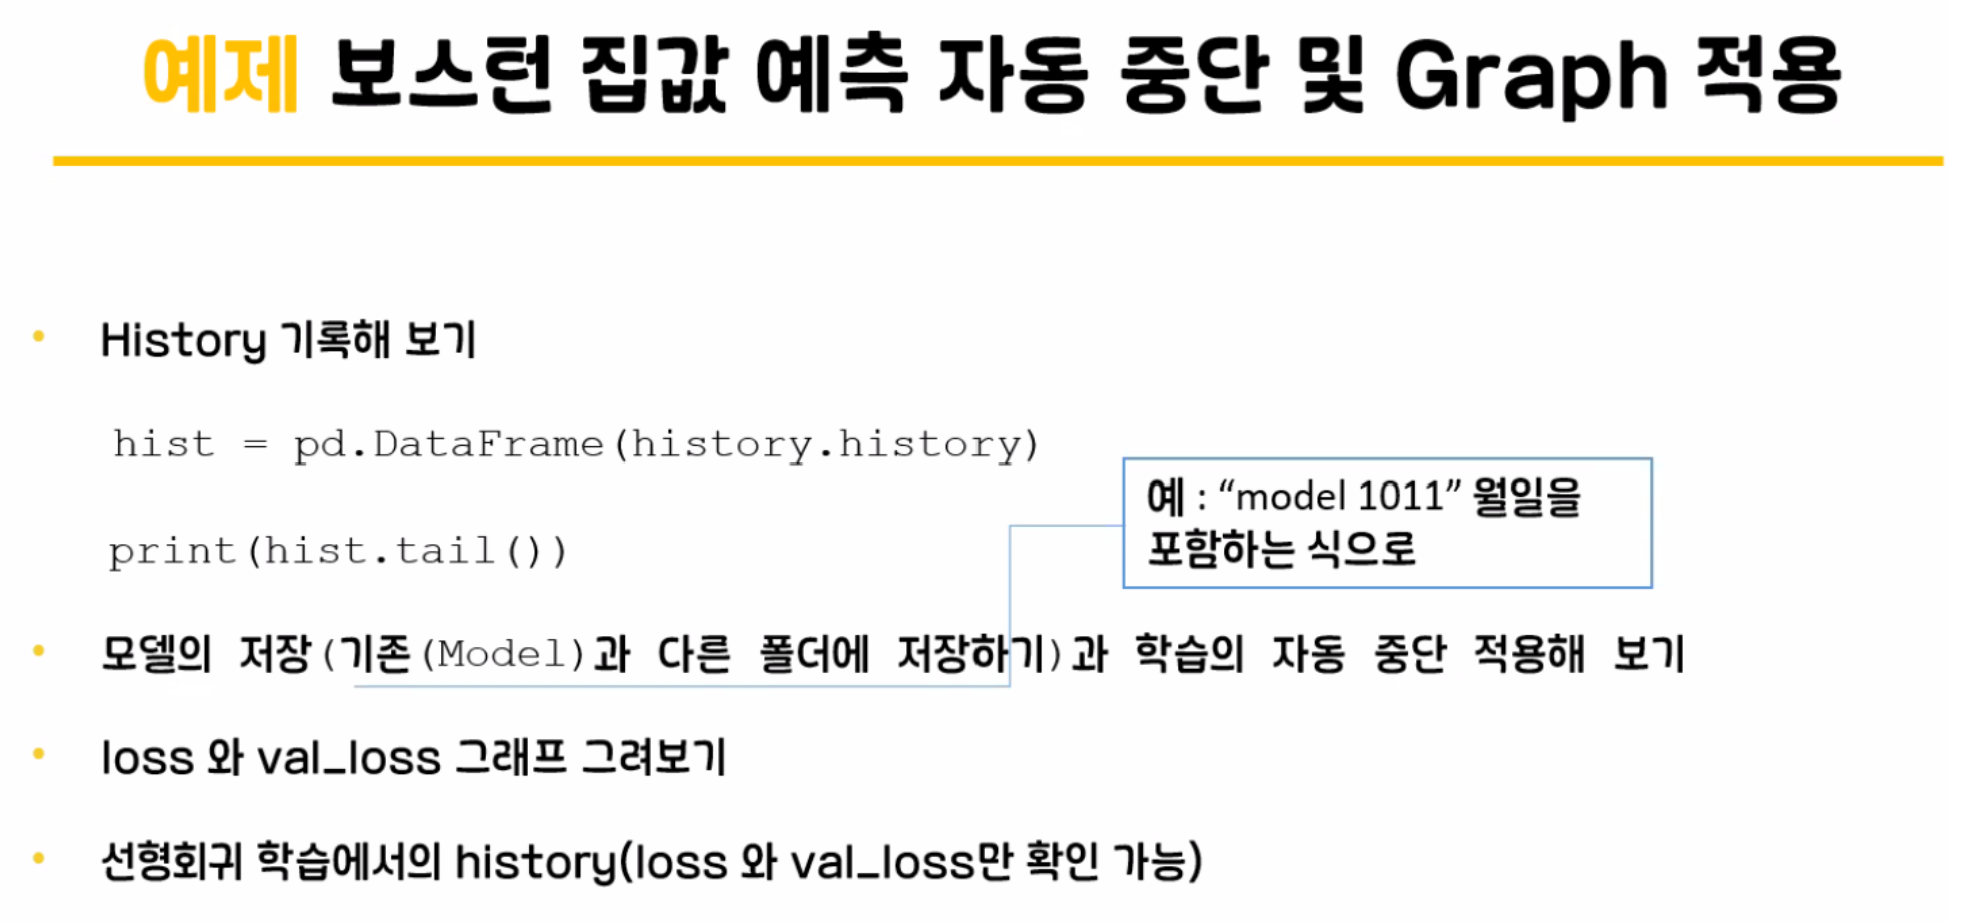

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 시드 고정
seed =0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
df_pre = pd.read_csv('housing.csv', delim_whitespace=True, header=None)
dataset = df_pre.values
# print(df.shape)
X = dataset[:, :13].astype(float)
Y = dataset[:, 13]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=seed)

# 모델 설정
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(6, activation='relu'))
model.add(Dense(1))

# 모델 컴파일
model.compile(loss='mean_squared_error', optimizer='adam')

# 자동 중단 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=50) 

MODEL_DIR = "./model/"
if not os.path.exists(MODEL_DIR):
   os.mkdir(MODEL_DIR)

# 모델 저장 조건 설정
model_path = MODEL_DIR + "{epoch:02d}-{val_loss:.2f}.keras"
checkpointer = ModelCheckpoint(filepath=model_path, monitor='val_loss', verbose=0, save_best_only=True)

# 모델 실행
history = model.fit(x_train, y_train, validation_split=0.2, epochs=2000, batch_size=10, verbose=0, callbacks=[checkpointer, early_stopping_callback])

y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# x값을 지정하고, 정확도는 파란색으로, 오차는 빨간색으로 표시
x_len = np.arange(len(y_loss))
plt.figure(figsize=(10, 5))
plt.plot(x_len, y_vloss, "o", c="violet", markersize=3, label='val_loss')
plt.plot(x_len, y_loss, "o", c="springgreen", markersize=3, label='loss')

plt.legend()
plt.show()

# 예측 값과 실제 값 비교
y_prediction = model.predict(x_test).flatten()
for i in range(10):
    label = y_test[i]
    prediction = y_prediction[i]
    print("실제가격: {:.3f}, 예상가격: {:.3f}".format(label, prediction))

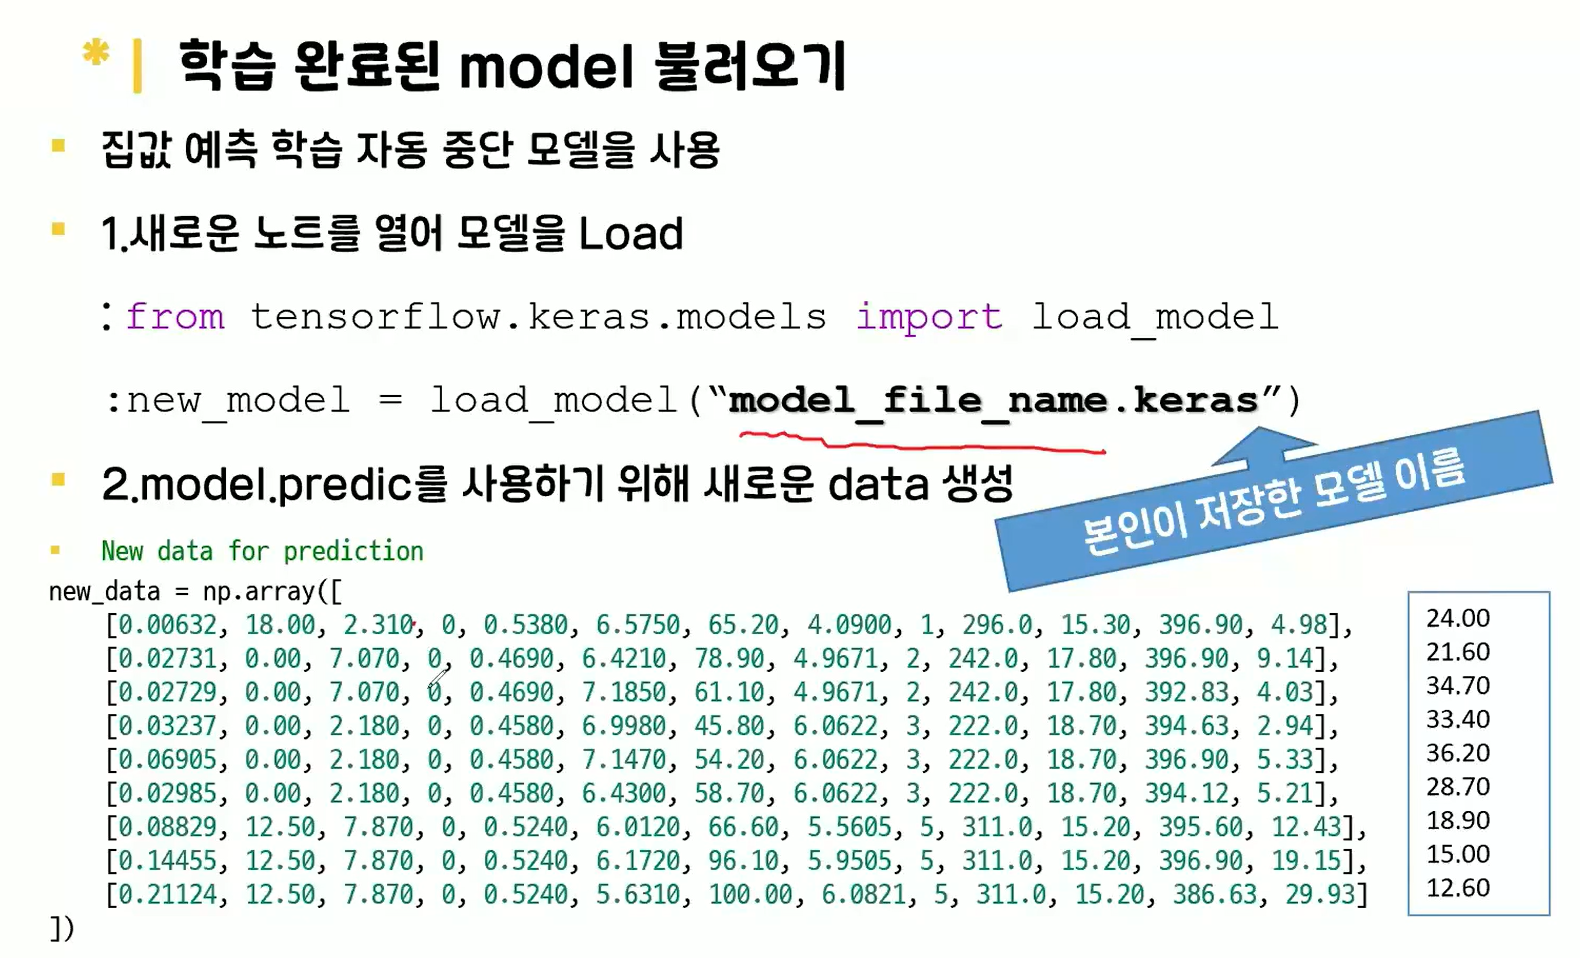

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 데이터 로드 및 전처리
df = pd.read_csv('housing.csv', delim_whitespace=True, header=None)
dataset = df.values

X = dataset[:, :13]
Y = dataset[:, 13] 
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

# 모델 로드
model = load_model('./model/264-25.22.keras')

# 모델 평가
loss = model.evaluate(x_test, y_test)
print(f'Loss : {loss}')

# 새로운 데이터 예측
new_data = np.array([
    [0.00632, 18.00, 2.310, 0, 0.5380, 6.5750, 65.20, 4.0900, 1, 296.0, 15.30, 396.90, 4.98],
    [0.02731, 0.00, 7.070, 0, 0.4690, 6.4210, 78.90, 4.9671, 2, 242.0, 17.80, 396.90, 9.14],
    [0.02729, 0.00, 7.070, 0, 0.4690, 7.1850, 61.10, 4.9671, 2, 242.0, 17.80, 392.83, 4.03],
    [0.03237, 0.00, 2.180, 0, 0.4580, 6.9980, 45.80, 6.0622, 3, 222.0, 18.70, 394.63, 2.94],
    [0.06905, 0.00, 2.180, 0, 0.4580, 7.1470, 54.20, 6.0622, 3, 222.0, 18.70, 396.90, 5.33],
    [0.02985, 0.00, 2.180, 0, 0.4580, 6.4300, 58.70, 6.0622, 3, 222.0, 18.70, 394.12, 5.21],
    [0.08829, 12.50, 7.870, 0, 0.5240, 6.0120, 66.60, 5.5605, 5, 311.0, 15.20, 395.60, 12.43],
    [0.14455, 12.50, 7.870, 0, 0.5240, 6.1720, 96.10, 5.9505, 5, 311.0, 15.20, 396.90, 19.15],
    [0.21124, 12.50, 7.870, 0, 0.5240, 5.6310, 100.00, 6.0821, 5, 311.0, 15.20, 386.63, 29.93]
])

predictions = model.predict(new_data).flatten()
print("Predictions :", predictions)

# 결과 출력
for i, pred in enumerate(predictions):
    print(f"{i+1}번째 지역 예상 집값 : {pred:.3f}")

# 그래프

# 실제 값
actual_values = np.array([24.0, 21.6, 34.7, 33.4, 36.2, 28.7, 18.9, 15.0, 12.6])

# 그래프 생성
plt.figure(figsize=(10, 6))

# 실제 값과 예측 값 표시
plt.plot(range(len(actual_values)), actual_values, label='Actual Values', marker='o')
plt.plot(range(len(predictions)), predictions, label='Predicted Values', marker='x')

# 그래프 레이블
plt.xlabel('Data Index')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices')
plt.legend()

# 그래프 출력
plt.show()

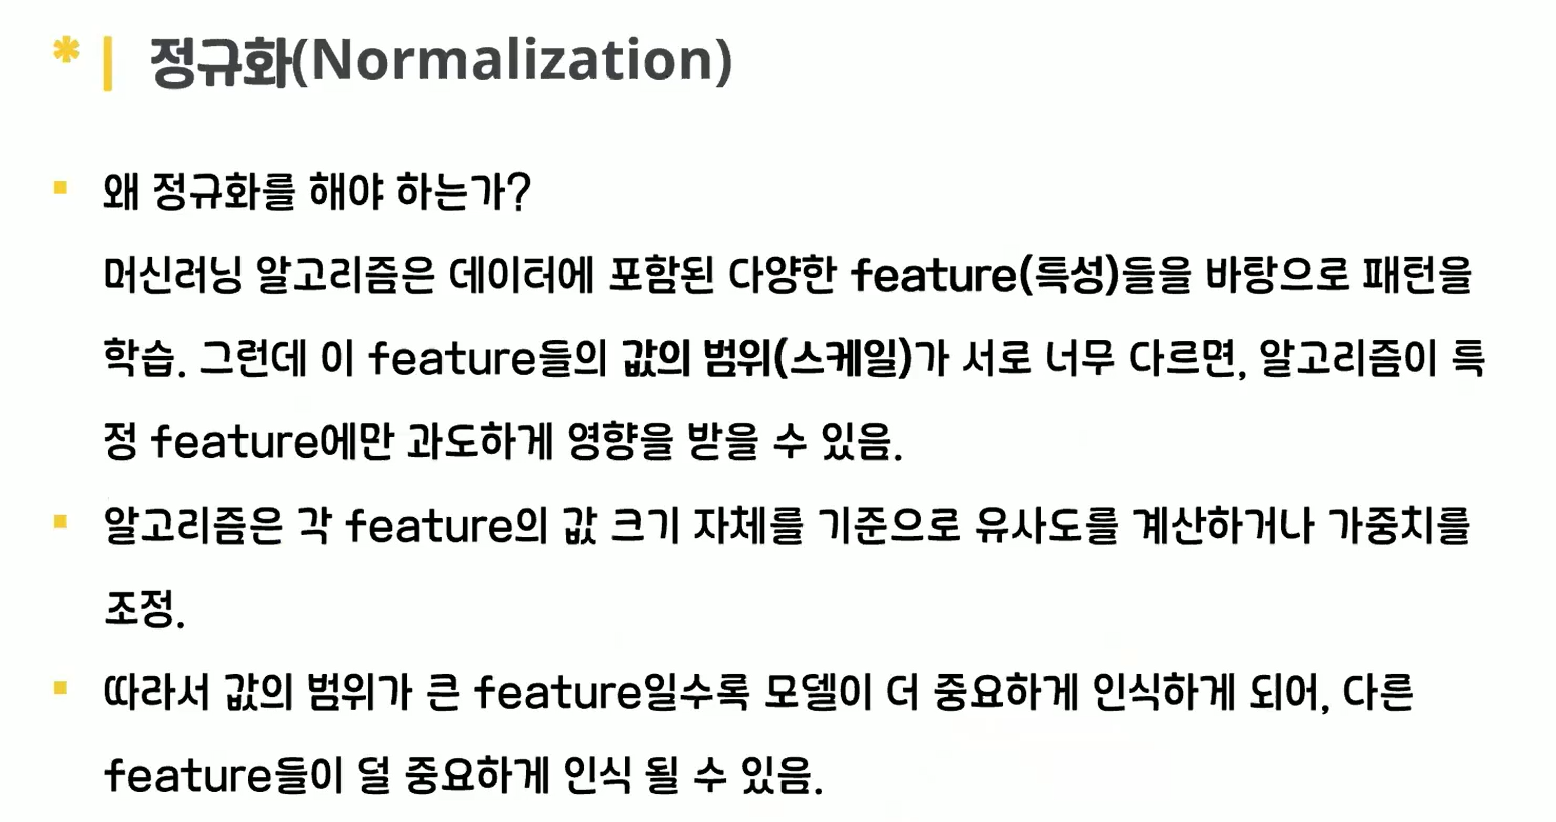

In [ ]:
# 값의 범위가 큰 속성에 대해서
# 1 ~ 10 -> 0 ~ 1 사이 값으로
# 1 ~ 1000 -> 0 ~ 1 사이 값으로 만든다.
# 모든 값들을 비슷한 수준으로 맞춰준다.
# 숫자 자체가 큰 속성이, 알고리즘의 계산 과정을 지배해서
# 숫자는 작지만 중요한 다른 속성들이 제 역할을 못하게 방해하지 않도록.

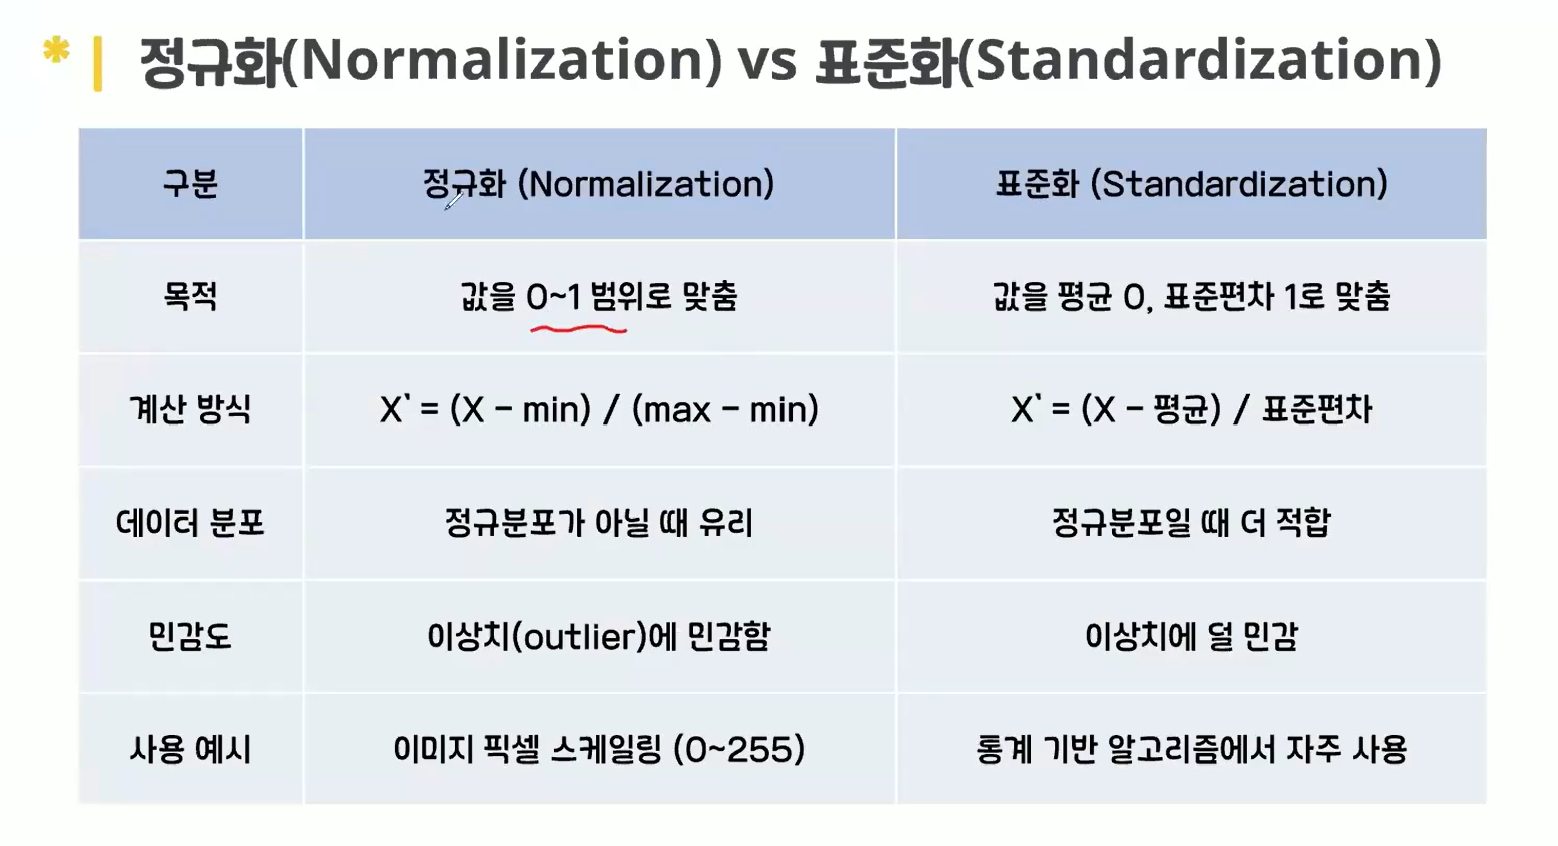

In [16]:
# 정규화 파이썬 코드 예시
# 분포 모양은 유지한 채, 전체 데이터의 크기를 0과 1사이의 고정된 틀 안으로 압축
def min_max_normalize(lst):
    normalized = []
    min_val = min(lst)
    max_val = max(lst)
    for value in lst:
        normalized_num = (value - min_val) / (max_val - min_val)
        normalized.append(normalized_num)
    return normalized

# 출력
print("정상 데이터:", min_max_normalize([10, 20, 30, 40, 50]))

정상 데이터: [0.0, 0.25, 0.5, 0.75, 1.0]


In [19]:
# 표준화 파이썬 코드 예시
# 평균을 중심으로 '평균으로부터 얼마나 멀리 떨어져 있는가'
import numpy as np

def z_score_normalize(lst):
    normalized = []
    mean = np.mean(lst)
    std = np.std(lst)
    for value in lst:
        normalized_num = (value - mean) / std
        normalized.append(normalized_num)
    return normalized

# 출력
result = [round(float(x), 2) for x in z_score_normalize([10, 20, 30, 40, 50])]
print("정상 데이터:", result)

정상 데이터: [-1.41, -0.71, 0.0, 0.71, 1.41]


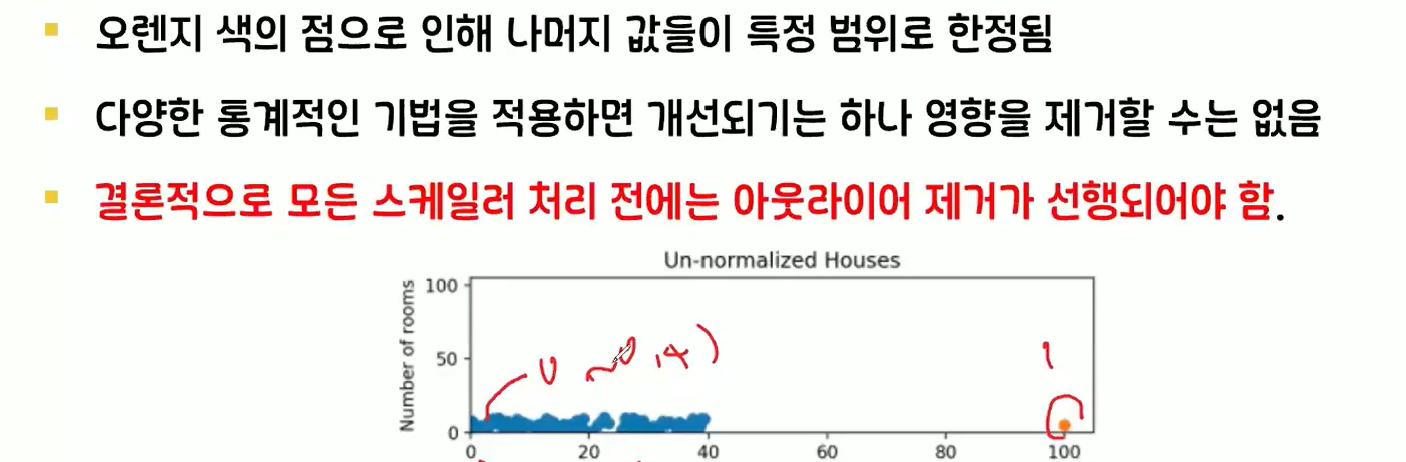

In [ ]:
# 오렌지 색 점 -> 이상치
# 정규화는, 이상치 제거가 선행되어야 한다.

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 시드 고정
seed =0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
df_pre = pd.read_csv('housing.csv', delim_whitespace=True, header=None)
dataset = df_pre.values
# print(df.shape)
X = dataset[:, :13].astype(float)
Y = dataset[:, 13]

# 정규화
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=seed)

# 정규화 그래프로 확인
# 기존
plt.boxplot(x_train)
plt.show()

# 정규화 후 : (X - 평균) / 표준편차
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)
x_train -= mean
x_train /= std
x_test -= mean
x_test /= std

# 정규화 후 그래프로 확인
plt.boxplot(x_train)
plt.show()

# 모델 설정
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(6, activation='relu'))
model.add(Dense(1))

# 모델 컴파일
model.compile(loss='mean_squared_error', optimizer='adam')

# 자동 중단 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=50) 

MODEL_DIR = "./model/"
if not os.path.exists(MODEL_DIR):
   os.mkdir(MODEL_DIR)

# 모델 저장 조건 설정
model_path = MODEL_DIR + "{epoch:02d}-{val_loss:.2f}.keras"
checkpointer = ModelCheckpoint(filepath=model_path, monitor='val_loss', verbose=0, save_best_only=True)

# 모델 실행
history = model.fit(x_train, y_train, validation_split=0.2, epochs=2000, batch_size=10, verbose=0, callbacks=[checkpointer, early_stopping_callback])

y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# x값을 지정하고, 정확도는 파란색으로, 오차는 빨간색으로 표시
x_len = np.arange(len(y_loss))
plt.figure(figsize=(10, 5))
plt.plot(x_len, y_vloss, "o", c="violet", markersize=3, label='val_loss')
plt.plot(x_len, y_loss, "o", c="springgreen", markersize=3, label='loss')

plt.legend()
plt.show()

# 예측 값과 실제 값 비교
y_prediction = model.predict(x_test).flatten()
for i in range(10):
    label = y_test[i]
    prediction = y_prediction[i]
    print("실제가격: {:.3f}, 예상가격: {:.3f}".format(label, prediction))